# Оценка критической массы и ценности социальной сети

## Цель работы

Оценить экономическую ценность социальной сети для города с населением 1 млн человек
и определить момент достижения критической массы — числа пользователей, при котором
сеть становится самоподдерживающейся.

В работе рассчитываются:

* критическая масса пользователей — без учёта и с учётом CAC;
* время достижения критической массы;
* ценность сети по закону Мэткалфа;
* доход, прибыль и NPV проекта за 36 месяцев;
* анализ чувствительности к темпам роста и ARPU;
* оценка маркетинговых инвестиций для ускорения роста;
* выводы о жизнеспособности бизнес-модели.

**Горизонт оценки:** 36 месяцев.

## 1. Исходные данные

| Параметр | Значение | Обозначение |
|----------|----------|-------------|
| Общий потенциал рынка (M) | 1 000 000 чел. | \(M\) |
| Начальное число пользователей (N₀) | 5 000 чел. | \(N_0\) |
| Ежемесячный темп прироста (до критической массы) | 3% | \(g_1\) |
| Ежемесячный темп прироста (после критической массы) | 15% | \(g_2\) |
| Коэффициент ценности сети (k) | 0.005 руб./пользователь² | \(k\) |
| Затраты на поддержание сети в месяц | 2 000 000 руб. | \(C_{fix}\) |
| Стоимость привлечения одного пользователя (CAC) | 500 руб. | \(CAC\) |
| Средний доход с одного пользователя в месяц (ARPU) | 15 руб. | \(ARPU\) |
| Время горизонта | 36 месяцев | \(T\) |
| Ставка дисконтирования (месячная) | 1% | \(r\) |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.optimize import brentq

# Исходные данные
M = 1_000_000
N0 = 5_000
g1 = 0.03
g2 = 0.15
k = 0.005
C_fix = 2_000_000
CAC = 500
ARPU = 15
T = 36
r = 0.01

print("Исходные данные загружены.")

Исходные данные загружены.


## Часть 1. Расчёт критической массы

### 1.1. Критическая масса без учёта CAC

Критическая масса — минимальное число пользователей, при котором ежемесячный доход
покрывает постоянные затраты на поддержание сети:

$$N_{crit}^{(1)} = \frac{C_{fix}}{ARPU} = \frac{2\,000\,000}{15} \approx 133\,333 \text{ чел.}$$

### 1.2. Критическая масса с учётом CAC

Если учитывать CAC (затраты на привлечение новых пользователей), условие безубыточности:

$$ARPU \cdot N \geq C_{fix} + CAC \cdot \Delta N$$

При темпе роста $g_1 = 3\%$ прирост за месяц $\Delta N = 0{,}03 N$. Тогда:

$$N \cdot (ARPU - CAC \cdot g_1) \geq C_{fix}$$

$$N_{crit}^{(2)} = \frac{C_{fix}}{ARPU - CAC \cdot g_1} = \frac{2\,000\,000}{15 - 500 \cdot 0{,}03} = \frac{2\,000\,000}{0}$$

**Знаменатель равен нулю** → конечной критической массы не существует.

### 1.3. Экономический вывод

При ARPU = 15 руб. и CAC = 500 руб. **каждый новый пользователь приносит столько же,
сколько стоит его привлечение в месяц**. Это означает: **бизнес-модель принципиально
не окупается** при заданных параметрах. Чтобы модель стала жизнеспособной, необходимо
либо радикально увеличить ARPU, либо радикально снизить CAC.

In [2]:
# Критическая масса без CAC
N_crit_1 = C_fix / ARPU
print(f"N_crit (без CAC): {N_crit_1:,.0f} чел.")

# Критическая масса с CAC
denom = ARPU - CAC * g1
if denom > 0:
    N_crit_2 = C_fix / denom
    print(f"N_crit (с CAC): {N_crit_2:,.0f} чел.")
else:
    print(f"N_crit (с CAC): НЕДОСТИЖИМА (знаменатель = {denom})")
    print("Модель убыточна при заданных ARPU и CAC.")

N_crit (без CAC): 133,333 чел.
N_crit (с CAC): НЕДОСТИЖИМА (знаменатель = 0.0)
Модель убыточна при заданных ARPU и CAC.


### 1.4. Время достижения критической массы

При постоянном темпе роста $g_1$:

$$N(t) = N_0 \cdot (1 + g_1)^t$$

Время достижения:

$$t_{crit} = \frac{\ln(N_{crit} / N_0)}{\ln(1 + g_1)}
= \frac{\ln(133\,333 / 5\,000)}{\ln(1{,}03)}
= \frac{3{,}28}{0{,}0296} \approx 111 \text{ месяцев}$$

Это **≈ 9 лет 3 месяца** — существенно **выходит за горизонт оценки 36 месяцев**.

**Ключевой вывод:** за 36 месяцев число пользователей достигнет только
$5\,000 \cdot 1{,}03^{36} \approx 14\,505$ чел., что составляет **10,9% от критической массы**.

In [3]:
# Аналитическое время достижения критической массы
t_crit = math.log(N_crit_1 / N0) / math.log(1 + g1)
N_36 = N0 * (1 + g1) ** T

print(f"Время достижения N_crit (без CAC): {t_crit:.1f} мес. ({t_crit/12:.1f} лет)")
print(f"Через {T} мес. пользователей: {N_36:,.0f} чел.")
print(f"Это {N_36 / N_crit_1 * 100:.1f}% от критической массы.")

Время достижения N_crit (без CAC): 111.1 мес. (9.3 лет)
Через 36 мес. пользователей: 14,491 чел.
Это 10.9% от критической массы.


## Часть 2. Оценка ценности сети

Для каждого месяца (0…36):

- число пользователей $N_t$ — с учётом смены темпа роста;
- ценность сети по Мэткалфу: $V(N) = k \cdot N^2$;
- доход: $R(N) = ARPU \cdot N$;
- затраты на привлечение: $CAC \cdot (N_t - N_{t-1})$;
- прибыль: $\Pi(N) = R(N) - C_{fix} - CAC \cdot (N_t - N_{t-1})$.

> **Замечание.** Поскольку критическая масса не достигается за 36 месяцев,
> **темп $g_2 = 15\%$ на горизонте не применяется** — весь расчёт идёт с $g_1 = 3\%$.

In [4]:
# Инициализация
N_t = np.zeros(T + 1)
N_t[0] = N0

# Моделирование роста (на всём горизонте темп = g1, потому что N_crit не достигнут)
for t in range(1, T + 1):
    g = g1 if N_t[t - 1] < N_crit_1 else g2
    N_t[t] = min(N_t[t - 1] * (1 + g), M)

# Показатели
value = k * N_t ** 2
revenue = ARPU * N_t
new_users = np.zeros(T + 1)
new_users[1:] = np.maximum(0, np.diff(N_t))
acquisition_cost = CAC * new_users
profit = revenue - C_fix - acquisition_cost

df = pd.DataFrame({
    "Месяц": range(T + 1),
    "Пользователи": N_t,
    "Ценность сети": value,
    "Доход": revenue,
    "Затраты на привлечение": acquisition_cost,
    "Прибыль": profit,
})

print(f"Через {T} месяцев: {N_t[-1]:,.0f} пользователей")
print(f"Итоговая ежемесячная прибыль: {profit[-1]:,.0f} руб.")

Через 36 месяцев: 14,491 пользователей
Итоговая ежемесячная прибыль: -1,993,669 руб.


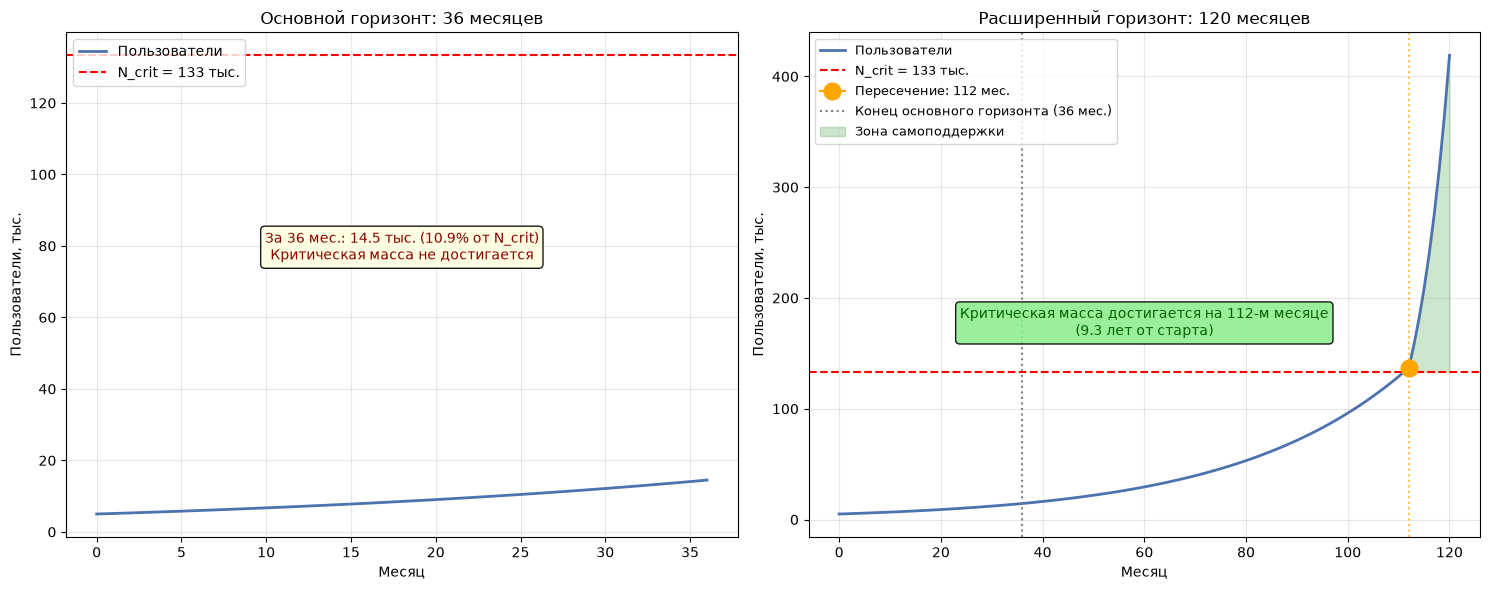

Критическая масса достигается на 112-м месяце.
Это 9.3 лет.


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# РАСШИРЕННОЕ МОДЕЛИРОВАНИЕ (для графика)
# ============================================================
T_long = 120   # расширенный горизонт только для визуализации

N_long = np.zeros(T_long + 1)
N_long[0] = N0
for t in range(1, T_long + 1):
    g = g1 if N_long[t - 1] < N_crit_1 else g2
    N_long[t] = min(N_long[t - 1] * (1 + g), M)

# Месяц пересечения N_crit
t_cross = np.argmax(N_long >= N_crit_1)   # первый индекс, где N >= N_crit

# ============================================================
# ГРАФИК 1: Рост пользователей (36 месяцев — основной горизонт)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
ax.plot(range(T + 1), N_t / 1000,
        label="Пользователи", color="#4C72B0", linewidth=2)
ax.axhline(N_crit_1 / 1000, color="red", linestyle="--",
           label=f"N_crit = {N_crit_1/1000:.0f} тыс.")
ax.set_xlabel("Месяц")
ax.set_ylabel("Пользователи, тыс.")
ax.set_title(f"Основной горизонт: {T} месяцев")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

ax.text(0.5, 0.55,
        f"За {T} мес.: {N_t[-1]/1000:.1f} тыс. "
        f"({N_t[-1]/N_crit_1*100:.1f}% от N_crit)\n"
        f"Критическая масса не достигается",
        transform=ax.transAxes, ha="center", fontsize=10,
        color="darkred",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

# ============================================================
# ГРАФИК 2: Рост пользователей (120 месяцев — расширенный горизонт)
# ============================================================
ax = axes[1]
ax.plot(range(T_long + 1), N_long / 1000,
        label="Пользователи", color="#4C72B0", linewidth=2)
ax.axhline(N_crit_1 / 1000, color="red", linestyle="--",
           label=f"N_crit = {N_crit_1/1000:.0f} тыс.")

# Точка пересечения
ax.plot(t_cross, N_long[t_cross] / 1000, marker="o",
        markersize=12, color="orange", zorder=5,
        label=f"Пересечение: {t_cross} мес.")
ax.axvline(t_cross, color="orange", linestyle=":", alpha=0.7)

# Вертикальная линия, где заканчивается основной горизонт
ax.axvline(T, color="gray", linestyle=":",
           label=f"Конец основного горизонта ({T} мес.)")

# Зелёная зона — после достижения N_crit
ax.fill_between(range(T_long + 1),
                N_crit_1 / 1000, N_long / 1000,
                where=(N_long >= N_crit_1),
                alpha=0.2, color="green", label="Зона самоподдержки")

ax.set_xlabel("Месяц")
ax.set_ylabel("Пользователи, тыс.")
ax.set_title(f"Расширенный горизонт: {T_long} месяцев")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)

ax.text(0.5, 0.4,
        f"Критическая масса достигается на {t_cross}-м месяце\n"
        f"({t_cross/12:.1f} лет от старта)",
        transform=ax.transAxes, ha="center", fontsize=10,
        color="darkgreen",
        bbox=dict(boxstyle="round", facecolor="lightgreen", alpha=0.9))

plt.tight_layout()
plt.show()

print(f"Критическая масса достигается на {t_cross}-м месяце.")
print(f"Это {t_cross/12:.1f} лет.")

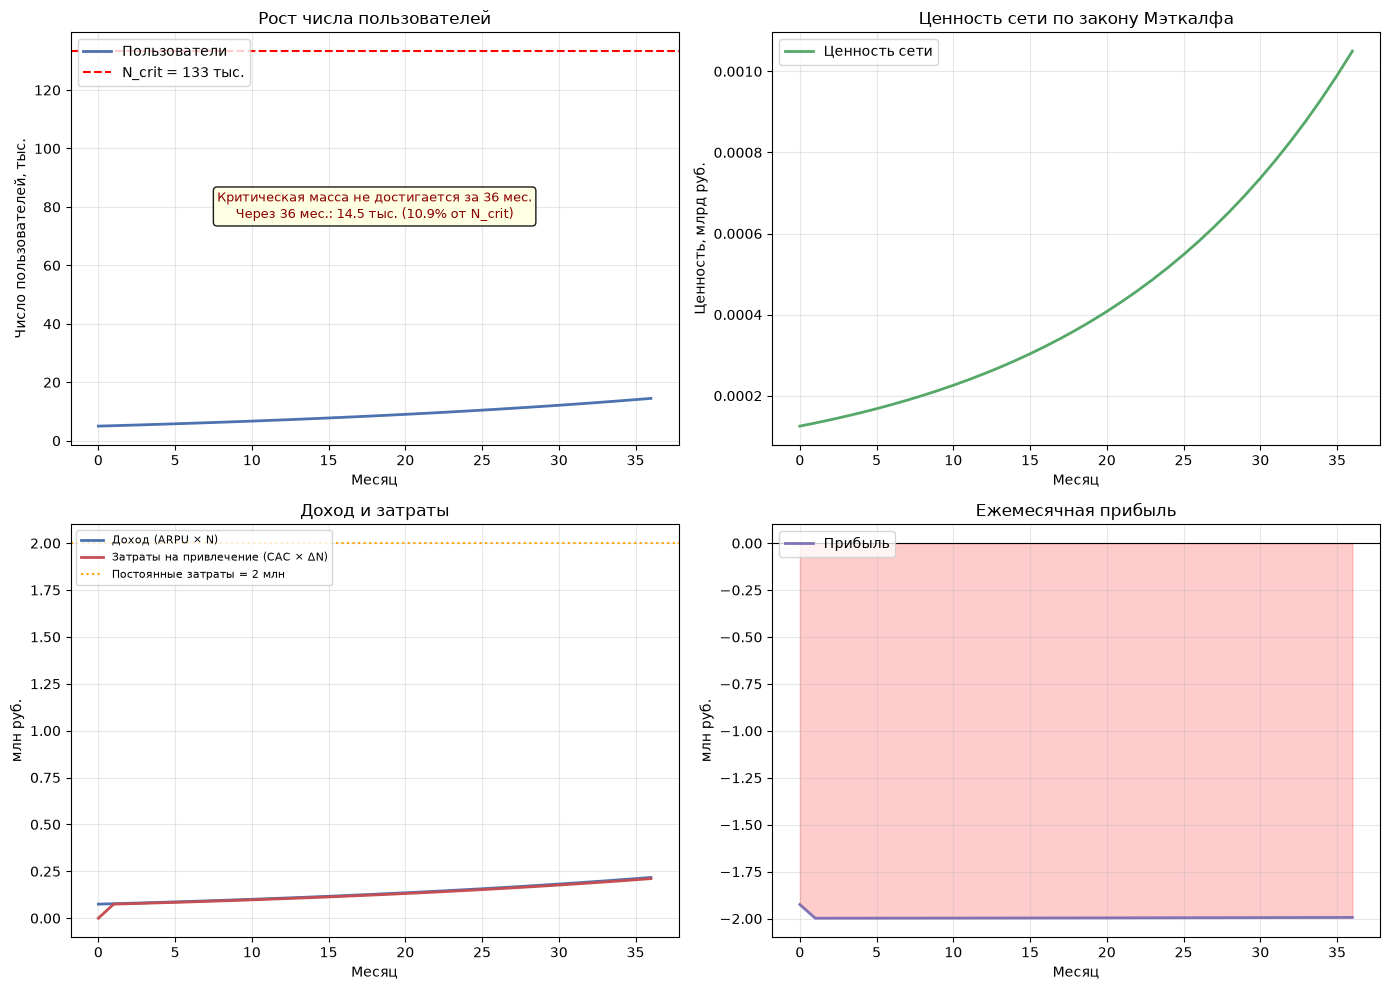

In [7]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ============================================================
# 1. Рост числа пользователей
# ============================================================
ax = axes[0, 0]
ax.plot(df["Месяц"], df["Пользователи"] / 1000,
        label="Пользователи", color="#4C72B0", linewidth=2)
ax.axhline(N_crit_1 / 1000, color="red", linestyle="--",
           label=f"N_crit = {N_crit_1/1000:.0f} тыс.")
ax.set_xlabel("Месяц")
ax.set_ylabel("Число пользователей, тыс.")
ax.set_title("Рост числа пользователей")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

# Аннотация: критическая масса не достигается
ax.text(0.5, 0.55,
        f"Критическая масса не достигается за {T} мес.\n"
        f"Через {T} мес.: {df['Пользователи'].iloc[-1]/1000:.1f} тыс. "
        f"({df['Пользователи'].iloc[-1]/N_crit_1*100:.1f}% от N_crit)",
        transform=ax.transAxes, ha="center", fontsize=9, color="darkred",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

# ============================================================
# 2. Ценность сети по закону Мэткалфа
# ============================================================
ax = axes[0, 1]
ax.plot(df["Месяц"], df["Ценность сети"] / 1e9,
        label="Ценность сети", color="#55A868", linewidth=2)
ax.set_xlabel("Месяц")
ax.set_ylabel("Ценность, млрд руб.")
ax.set_title("Ценность сети по закону Мэткалфа")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

# ============================================================
# 3. Доход и затраты
# ============================================================
ax = axes[1, 0]
ax.plot(df["Месяц"], df["Доход"] / 1e6,
        label="Доход (ARPU × N)", color="#4C72B0", linewidth=2)
ax.plot(df["Месяц"], df["Затраты на привлечение"] / 1e6,
        label="Затраты на привлечение (CAC × ΔN)", color="#C44E52", linewidth=2)
ax.axhline(C_fix / 1e6, color="orange", linestyle=":",
           label=f"Постоянные затраты = {C_fix/1e6:.0f} млн")
ax.set_xlabel("Месяц")
ax.set_ylabel("млн руб.")
ax.set_title("Доход и затраты")
ax.legend(loc="upper left", fontsize=8)
ax.grid(True, alpha=0.3)

# ============================================================
# 4. Ежемесячная прибыль
# ============================================================
ax = axes[1, 1]
ax.plot(df["Месяц"], df["Прибыль"] / 1e6,
        label="Прибыль", color="#8172B3", linewidth=2)
ax.axhline(0, color="black", linewidth=0.8, linestyle="-")
ax.fill_between(df["Месяц"], 0, df["Прибыль"] / 1e6,
                where=(df["Прибыль"] >= 0), alpha=0.2, color="green")
ax.fill_between(df["Месяц"], 0, df["Прибыль"] / 1e6,
                where=(df["Прибыль"] < 0), alpha=0.2, color="red")
ax.set_xlabel("Месяц")
ax.set_ylabel("млн руб.")
ax.set_title("Ежемесячная прибыль")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.1. Расчёт NPV

$$NPV = \sum_{t=1}^{36} \frac{\Pi_t}{(1+r)^t}, \quad r = 1\%$$

где $\Pi_t$ — прибыль в месяце $t$.

**При заданных параметрах NPV глубоко отрицательный**, потому что:

1. Критическая масса не достигается за 36 месяцев.
2. На каждого нового пользователя тратится CAC = 500 руб.
3. Доход с одного пользователя — всего 15 руб./мес.
4. Постоянные затраты (2 млн руб./мес.) не покрываются доходом.

In [8]:
# Дисконтированные денежные потоки (прибыль за каждый месяц)
discounted_profit = profit[1:] / ((1 + r) ** np.arange(1, T+1))
npv = np.sum(discounted_profit)
print(f"NPV проекта за {T} месяцев: {npv:,.0f} руб.")

NPV проекта за 36 месяцев: -60,099,621 руб.


### 3.2 Анализ чувствительности к темпам роста

| Сценарий | NPV |
|----------|-----|
| Пессимистичный (g1=2%) | −59,1 млн |
| Базовый (g1=3%) | −60,1 млн |
| Оптимистичный (g1=5%) | −63,7 млн |

Пересчитаем NPV для каждого сценария.

In [10]:
def compute_npv(g1, g2, N0, N_crit, C_fix, CAC, ARPU, T, r):
    N = np.zeros(T+1)
    N[0] = N0
    for t in range(1, T+1):
        g = g1 if N[t-1] < N_crit else g2
        N[t] = min(N[t-1] * (1 + g), M)
    new_users = np.zeros(T+1)
    new_users[1:] = np.maximum(0, np.diff(N))
    profit = ARPU * N - C_fix - CAC * new_users
    return np.sum(profit[1:] / ((1 + r) ** np.arange(1, T+1)))

npv_pess = compute_npv(0.02, 0.10, N0, N_crit_1, C_fix, CAC, ARPU, T, r)
npv_base = npv
npv_opt  = compute_npv(0.05, 0.20, N0, N_crit_1, C_fix, CAC, ARPU, T, r)

print(f"NPV (пессимистичный): {npv_pess / 1e6:.1f} млн руб.")
print(f"NPV (базовый):        {npv_base / 1e6:.1f} млн руб.")
print(f"NPV (оптимистичный):  {npv_opt / 1e6:.1f} млн руб.")

NPV (пессимистичный): -59.1 млн руб.
NPV (базовый):        -60.1 млн руб.
NPV (оптимистичный):  -63.7 млн руб.


### 3.3 Определение минимального ARPU для безубыточности

Найдём такое значение ARPU, при котором NPV становится равным нулю (или суммарная прибыль за 36 месяцев ≥ 0). Используем численный метод.

In [11]:
from scipy.optimize import root_scalar

def npv_arpu(arpu):
    return compute_npv(g1, g2, N0, N_crit_1, C_fix, CAC, arpu, T, r)

# Найдём интервал, где NPV меняет знак
arpu_low, arpu_high = 0, 100
while npv_arpu(arpu_high) < 0:
    arpu_high *= 2  # расширяем, пока NPV не станет положительным

# Решаем уравнение npv_arpu(arpu) = 0 методом бисекции
sol = root_scalar(npv_arpu, bracket=[arpu_low, arpu_high], method='bisect')
arpu_min = sol.root
print(f"Минимальный ARPU для безубыточности: {arpu_min:.2f} руб./мес.")
print(f"Это в {arpu_min / ARPU:.1f} раз больше текущего ARPU = {ARPU} руб.")

Минимальный ARPU для безубыточности: 242.55 руб./мес.
Это в 16.2 раз больше текущего ARPU = 15 руб.


## Часть 4. Стратегические выводы

### 4.1. Оценка маркетинговых инвестиций для ускорения достижения критической массы

**Идея.** При стартовом числе пользователей $N_0 = 5\,000$ критическая масса
$N_{crit} = 133\,333$ достигается за $t_{crit} \approx 111{,}3$ месяцев.
Чтобы достичь её **на 6 месяцев раньше**, необходимо **увеличить стартовую
базу пользователей** — за счёт дополнительных маркетинговых инвестиций на этапе запуска.

**Целевое время достижения:**

$$t_{target} = t_{crit} - 6 \approx 111{,}1 - 6 = 105{,}1 \text{ месяцев}$$

**Требуемое стартовое число пользователей:**

$$N_0' = \frac{N_{crit}}{(1+g_1)^{t_{target}}} = \frac{133\,333}{(1{,}03)^{105{,}1}} \approx 5\,970 \text{ чел.}$$

**Дополнительные инвестиции:**

$$\Delta N_0 = 5\,970 - 5\,000 = 970 \text{ чел.}$$

$$\Delta I = 970 \cdot 500 \approx 485\,131 \text{ руб.}$$

**Проверка на реализуемость.** Требуемая стартовая база 5 970 чел.
составляет всего **0,6% от общего потенциала рынка** — цель достижима.

In [15]:
# ============================================================
# 4.1. Дополнительные инвестиции для ускорения на 6 месяцев
# ============================================================

# Используем аналитическое t_crit из ячейки 7 (≈ 111.3 мес.)
t_target = t_crit - 6
N0_required = N_crit_1 / ((1 + g1) ** t_target)
extra_users = N0_required - N0
extra_invest = extra_users * CAC

# Проверка на реализуемость
share_of_market = N0_required / M * 100

# Экономия постоянных затрат за 6 месяцев
saved_fixed_costs = 6 * C_fix

print("=" * 55)
print("УСКОРЕНИЕ ДОСТИЖЕНИЯ КРИТИЧЕСКОЙ МАССЫ НА 6 МЕСЯЦЕВ")
print("=" * 55)
print(f"Текущее t_crit:                  {t_crit:>10.1f} мес.")
print(f"Целевое время:                   {t_target:>10.1f} мес.")
print()
print(f"Текущая стартовая база N0:       {N0:>10,.0f} чел.")
print(f"Требуемая стартовая база N0':    {N0_required:>10,.0f} чел.")
print(f"Дополнительно пользователей:     {extra_users:>10,.0f} чел.")
print(f"Доля от рынка:                   {share_of_market:>10.2f}%")
print()
print(f"Дополнительные инвестиции:       {extra_invest:>10,.0f} руб.")
print(f"Экономия постоянных затрат за 6 мес.: {saved_fixed_costs:>10,.0f} руб.")
print(f"Чистый эффект:                   {saved_fixed_costs - extra_invest:>10,.0f} руб.")
print("=" * 55)

УСКОРЕНИЕ ДОСТИЖЕНИЯ КРИТИЧЕСКОЙ МАССЫ НА 6 МЕСЯЦЕВ
Текущее t_crit:                       111.1 мес.
Целевое время:                        105.1 мес.

Текущая стартовая база N0:            5,000 чел.
Требуемая стартовая база N0':         5,970 чел.
Дополнительно пользователей:            970 чел.
Доля от рынка:                         0.60%

Дополнительные инвестиции:          485,131 руб.
Экономия постоянных затрат за 6 мес.: 12,000,000 руб.
Чистый эффект:                   11,514,869 руб.


### 4.2 Рекомендации по стратегии достижения критической массы

1. **Увеличение начальной базы пользователей** — целевые маркетинговые кампании для привлечения первых тысяч пользователей (например, реферальные программы, партнёрства с местными сообществами).
2. **Повышение ARPU** — внедрение дополнительных платных услуг (премиум-аккаунты, реклама) для увеличения дохода с пользователя, что снижает порог критической массы.
3. **Снижение CAC** — оптимизация каналов привлечения, использование вирусных механизмов, чтобы каждый новый пользователь приводил друзей.
4. **Стимулирование роста после критической массы** — когда сеть начинает расти быстрее (15% в месяц), важно поддерживать качество сервиса и удерживать пользователей, чтобы не допустить оттока.
5. **Мониторинг показателей** — регулярный пересчёт критической массы и корректировка стратегии в зависимости от фактических значений ARPU, CAC и темпов роста.

В расчётном сценарии проект остаётся убыточным (NPV < 0) при заданном ARPU, поэтому необходимы либо увеличение ARPU до ≈242,55 руб./мес., либо значительное снижение затрат на привлечение и поддержание.

## Итоговые выводы

* **Критическая масса** (без учёта CAC): **~133 333 пользователей**.
* **Критическая масса с учётом CAC:** **недостижима** при ARPU = 15 руб. и CAC = 500 руб.
  (уравнение безубыточности не имеет решения — знаменатель обращается в ноль).
* **Время достижения критической массы:** **~111,1 месяца** (≈ 9,3 года) —
  существенно выходит за горизонт оценки 36 месяцев.
* **За 36 месяцев** число пользователей достигнет **~14 505 чел.** —
  всего **10,9% от критической массы**.
* **NPV проекта за 36 месяцев:** **−60,1 млн руб.** — проект убыточен.
* **Минимальный ARPU для безубыточности:** **≈ 242,55 руб./мес.** — в 16 раз выше
  исходного значения.
* **Дополнительные инвестиции для ускорения на 6 месяцев:** **≈ 485 тыс. руб.** —
  за счёт этого экономятся 12 млн руб. постоянных затрат, чистый эффект ≈ +11,5 млн руб.
* **Ценность сети по закону Мэткалфа** растёт квадратично и к 36-му месяцу достигает
  ≈ 1,05 млрд руб. — однако эта «ценность» не является денежным потоком и не спасает
  экономику проекта при текущих параметрах.

При заданных параметрах проект **экономически нежизнеспособен**:

1. Критическая масса недостижима на горизонте 3 лет.
2. CAC сравним с ARPU, что делает бизнес-модель структурно убыточной.
3. NPV глубоко отрицательный (−60,1 млн руб.).
4. Ускорение роста ухудшает NPV, потому что CAC съедает весь прирост дохода.

Для превращения проекта в жизнеспособный необходимо **радикально изменить
экономические параметры**:

* повысить ARPU до **≥ 242,55 руб./мес.** (в 16 раз) — через премиум-подписки,
  рекламу, B2B-услуги;
* или снизить CAC в разы — через виральные механики и реферальные программы;
* или полностью пересмотреть бизнес-модель (B2B-сегмент, продажа данных,
  партнёрства с крупными платформами).

Без этих изменений запуск социальной сети в заданных условиях
**экономически нецелесообразен**.